## Persiapan Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

/Users/liliktriyawan/Lilik Triyawan/Python/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Load Data

In [2]:
df = pd.read_csv("Bitcoin3.csv")
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.set_index("Date").sort_index()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53150 entries, 2017-09-21 09:00:00 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8 MB


In [4]:
df.describe()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


In [5]:
df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


### Analisis Dekomposisi

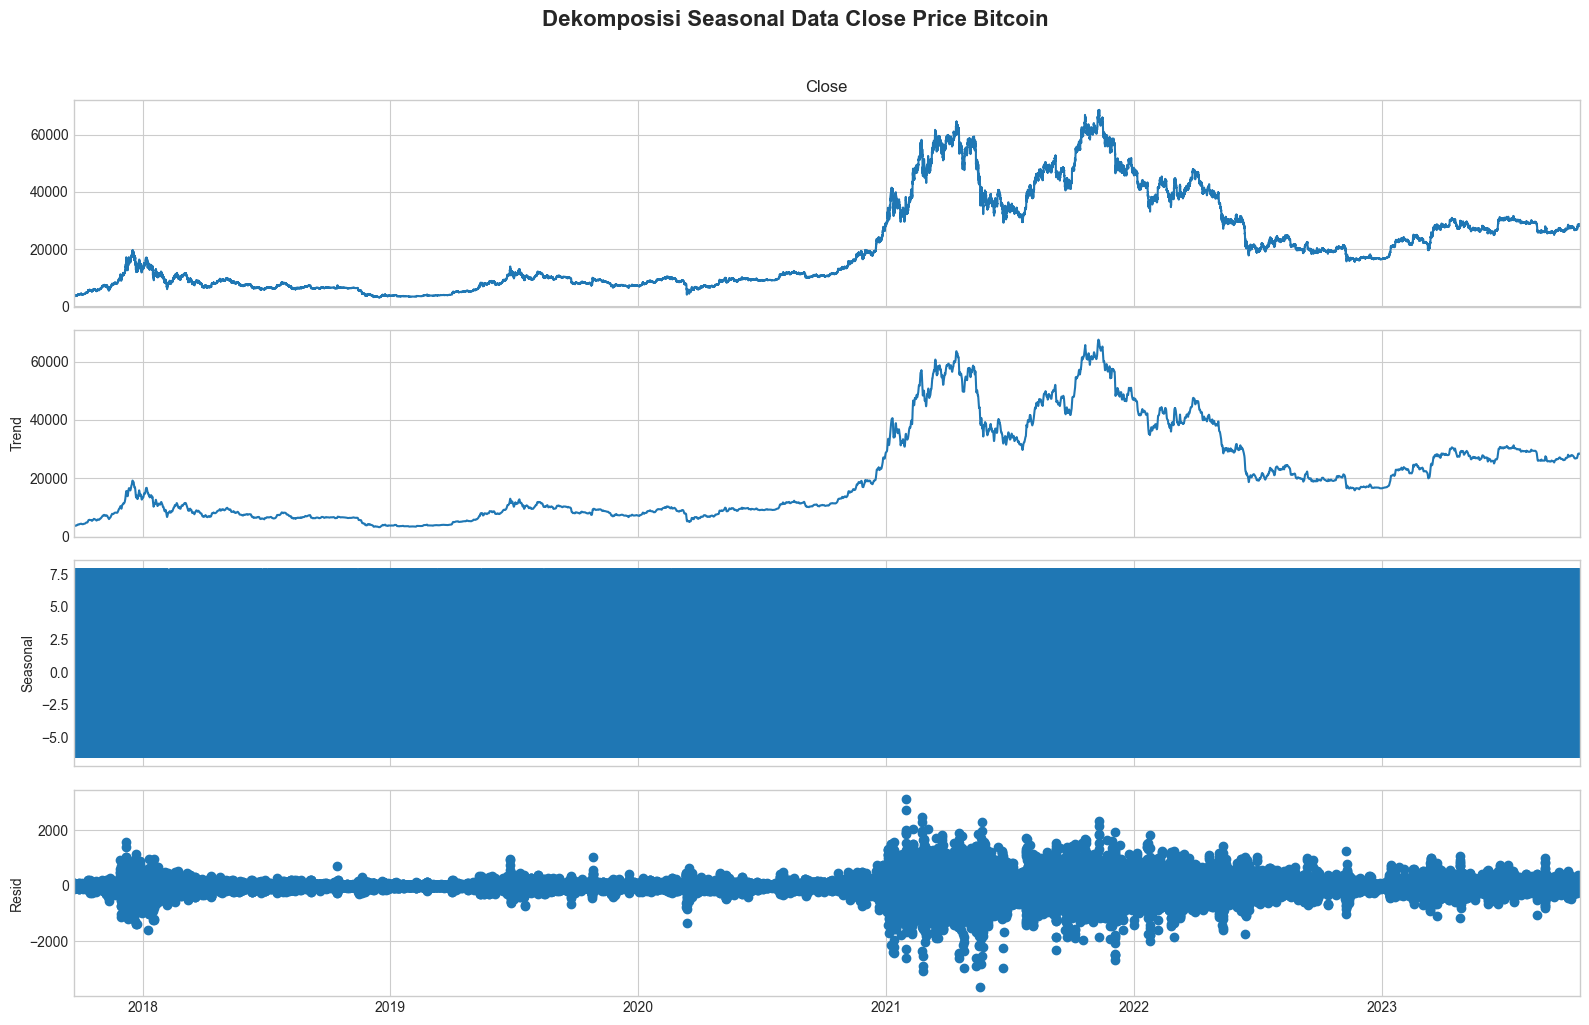

In [6]:
decompose_result = seasonal_decompose(df["Close"], model="additive", period=24)

fig = decompose_result.plot()
fig.set_size_inches(16, 10)
plt.suptitle("Dekomposisi Seasonal Data Close Price Bitcoin", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Analisis Lag ACF & PACF untuk menentukan Window Size

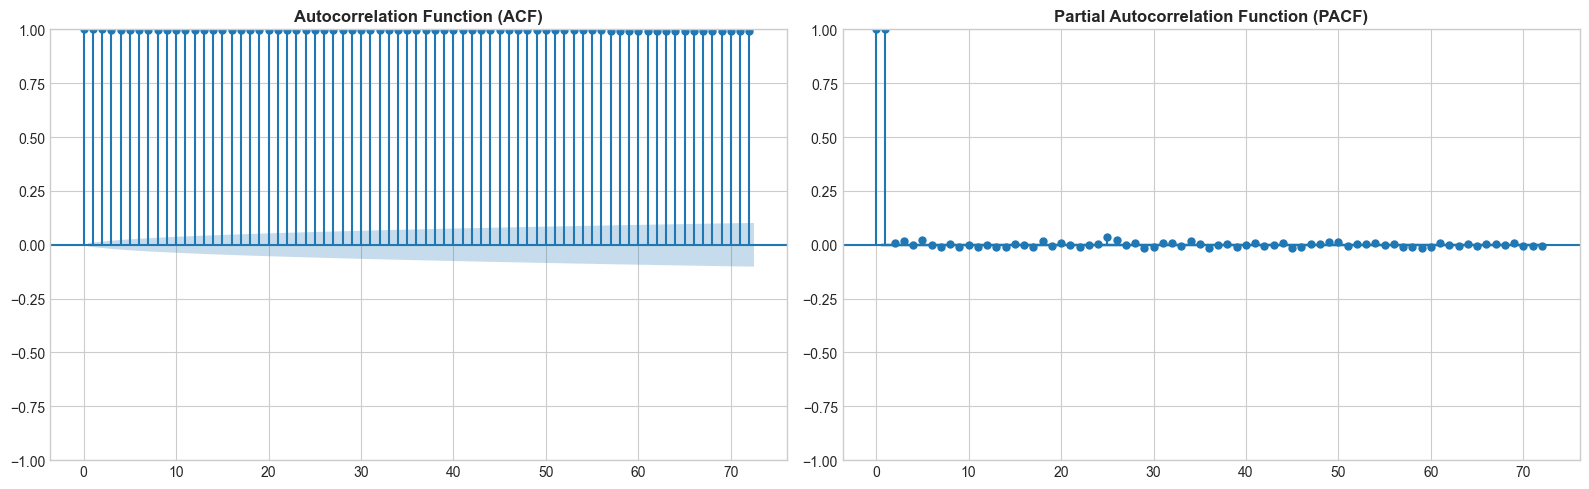

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df["Close"].dropna(), lags=72, ax=ax[0])
plot_pacf(df["Close"].dropna(), lags=72, ax=ax[1])
ax[0].set_title("Autocorrelation Function (ACF)", fontweight="bold")
ax[1].set_title("Partial Autocorrelation Function (PACF)", fontweight="bold")
plt.tight_layout()
plt.show()

### Heatmap Korelasi

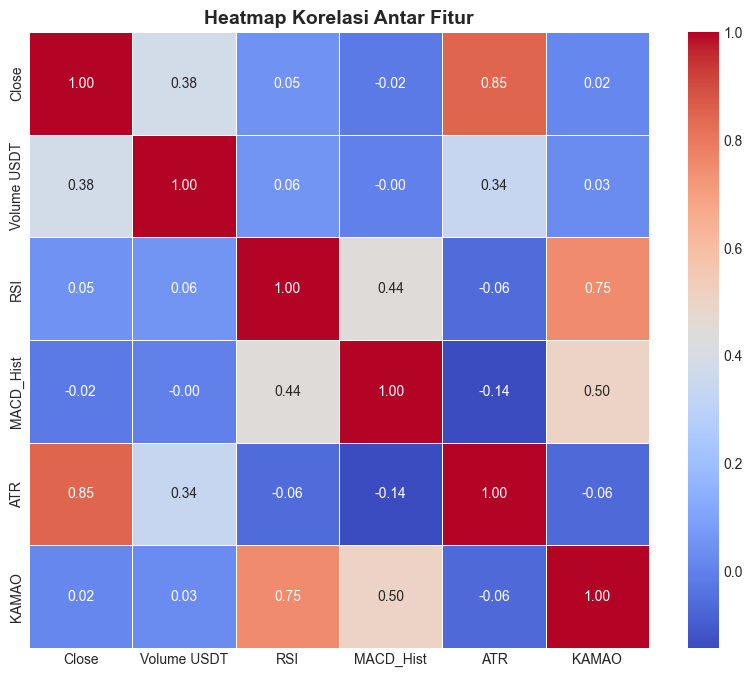

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[["Close", "Volume USDT", "RSI", "MACD_Hist", "ATR", "KAMAO"]].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur", fontweight="bold", fontsize=14)
plt.show()

### Feature engineering dengan menggunakan Rolling Statistic

In [9]:
df["Rolling_Mean_24"] = df["Close"].rolling(window=24).mean()
df["Rolling_Std_24"] = df["Close"].rolling(window=24).std()

df = df.dropna()

TARGET_COL = "Close"
FEATURES = ["Close", "Volume USDT", "RSI", "MACD_Hist", "ATR", "KAMAO", "Rolling_Mean_24", "Rolling_Std_24"]
WINDOW_SIZE = 48
FORECAST_STEPS = 24

print(f"Total data setelah drop NaN: {len(df)}")
print(f"Jumlah fitur: {len(FEATURES)} ({FEATURES})")
print(f"Window Size: {WINDOW_SIZE} (berdasarkan hasil analisis ACF/PACF)")
print(f"Forecast Steps: {FORECAST_STEPS}")

Total data setelah drop NaN: 53127
Jumlah fitur: 8 (['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'Rolling_Mean_24', 'Rolling_Std_24'])
Window Size: 48 (berdasarkan hasil analisis ACF/PACF)
Forecast Steps: 24


### Split data dan Normalisasi data

In [10]:
data_values = df[FEATURES].values
n = len(data_values)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data_values[:train_end]
val_data = data_values[train_end:val_end]
test_data = data_values[val_end:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

target_idx = FEATURES.index(TARGET_COL)
print(f"Train: {train_scaled.shape}")
print(f"Val: {val_scaled.shape}")
print(f"Test: {test_scaled.shape}")
print(f"Column '{TARGET_COL}', index: {target_idx}")

Train: (37188, 8)
Val: (7969, 8)
Test: (7970, 8)
Column 'Close', index: 0


### Membuat Sequences & Pipeline tf.data.Dataset

In [11]:
def create_sequences(data, win_size, fh_size, tgt_idx):
    X, y = [], []
    for i in range(len(data) - win_size - fh_size + 1):
        X.append(data[i : i + win_size])
        y.append(data[i + win_size : i + win_size + fh_size, tgt_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, FORECAST_STEPS, target_idx)
X_val, y_val = create_sequences(val_scaled, WINDOW_SIZE, FORECAST_STEPS, target_idx)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE, FORECAST_STEPS, target_idx)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"\ntf.data.Dataset pipeline berhasil dibuat dengan (batch_size={BATCH_SIZE})")

X_train: (37117, 48, 8), y_train: (37117, 24)
X_val: (7898, 48, 8), y_val: (7898, 24)
X_test: (7899, 48, 8), y_test: (7899, 24)

tf.data.Dataset pipeline berhasil dibuat dengan (batch_size=128)


### Custom Layer

In [12]:
# Custom Dense Layer
@tf.keras.utils.register_keras_serializable()
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        
    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super(CustomDense, self).build(input_shape)
        
    def call(self, inputs):
        output = tf.matmul(inputs, self.kernel) + self.bias
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(CustomDense, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation)
        })
        return config

In [13]:
# Custom LeakyReLU
@tf.keras.utils.register_keras_serializable()
class CustomLeakyReLU(tf.keras.layers.Layer):
    def __init__(self, alpha=0.01, **kwargs):
        super(CustomLeakyReLU, self).__init__(**kwargs)
        self.alpha = float(alpha)
        
    def call(self, inputs):
        return tf.maximum(self.alpha * inputs, inputs)
        
    def get_config(self):
        config = super(CustomLeakyReLU, self).get_config()
        config.update({'alpha': self.alpha})
        return config

In [14]:
# Custom Multi-Head Attention
@tf.keras.utils.register_keras_serializable()
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        
    def build(self, input_shape):
        d_model = input_shape[-1]
        self.wq = self.add_weight(name='wq', shape=(d_model, self.num_heads * self.key_dim), initializer='glorot_uniform', trainable=True)
        self.wk = self.add_weight(name='wk', shape=(d_model, self.num_heads * self.key_dim), initializer='glorot_uniform', trainable=True)
        self.wv = self.add_weight(name='wv', shape=(d_model, self.num_heads * self.key_dim), initializer='glorot_uniform', trainable=True)
        self.wo = self.add_weight(name='wo', shape=(self.num_heads * self.key_dim, d_model), initializer='glorot_uniform', trainable=True)
        self.bo = self.add_weight(name='bo', shape=(d_model,), initializer='zeros', trainable=True)
        super(CustomMultiHeadAttention, self).build(input_shape)
        
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])
        
    def call(self, query, key, value):
        batch_size = tf.shape(query)[0]
        
        q = self.split_heads(tf.matmul(query, self.wq), batch_size)
        k = self.split_heads(tf.matmul(key, self.wk), batch_size)
        v = self.split_heads(tf.matmul(value, self.wv), batch_size)
        
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(self.key_dim, tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        
        output = tf.matmul(attention_weights, v)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.num_heads * self.key_dim))
        
        return tf.matmul(concat_attention, self.wo) + self.bo
        
    def get_config(self):
        config = super(CustomMultiHeadAttention, self).get_config()
        config.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return config

### LSTM Baseline dengan custom layer

In [15]:
def build_baseline_lstm(window, features, forecast_steps):
    inputs = tf.keras.layers.Input(shape=(window, features))
    
    # LSTM layer 1
    x = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)
    
    # Custom Multi-Head Attention
    attn_out = CustomMultiHeadAttention(num_heads=2, key_dim=16)(x, x, x)
    x = x + attn_out
    
    # LSTM layer 2
    x = tf.keras.layers.LSTM(64, return_sequences=False)(x)
    
    # Custom LeakyReLU
    x = CustomLeakyReLU(alpha=0.01)(x)
    
    # Custom Dense layer
    outputs = CustomDense(forecast_steps)(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="Baseline_LSTM")

model_baseline = build_baseline_lstm(WINDOW_SIZE, len(FEATURES), FORECAST_STEPS)
model_baseline.summary()

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 48, 64)    │     18,688 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, None, 64)  │      8,256 │ lstm[0][0],       │
│ (CustomMultiHeadAt… │                   │            │ lstm[0][0],       │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 64)    │          0 │ lstm[0][0],       │
│                     │                   │            │ custom_multi_hea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     33,024 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_leaky_re_lu  │ (None, 64)        │          0 │ lstm_1[0][0]      │
│ (CustomLeakyReLU)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense        │ (None, 24)        │      1,560 │ custom_leaky_re_… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,528 (240.34 KB)

 Trainable params: 61,528 (240.34 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_baseline.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_base = model_baseline.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    verbose=1
)

Epoch 1/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - loss: 0.0015 - mae: 0.0223 - val_loss: 5.0147e-04 - val_mae: 0.0176
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 8.9175e-04 - mae: 0.0180 - val_loss: 6.6677e-04 - val_mae: 0.0215
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 1.6651e-04 - mae: 0.0083 - val_loss: 8.5201e-04 - val_mae: 0.0255
Epoch 4/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 9.5871e-05 - mae: 0.0061 - val_loss: 4.3317e-04 - val_mae: 0.0166
Epoch 5/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 7.7798e-05 - mae: 0.0053 - val_loss: 2.9662e-04 - val_mae: 0.0132
Epoch 6/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 7.4082e-05 - mae: 0.0050 - val_loss: 4.4221e-04 - val_mae: 0.0172
Epoch 7/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 7.4608e-05 - mae: 0.0050 - val_loss: 3.5154e-04 - val_mae: 0.0150
Epoch 8/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 6.9099e-05 - mae: 0.0049 - val_loss: 3.0781e-0

### Seq2seq Model LSTM Subclassing

In [17]:
@tf.keras.utils.register_keras_serializable()
class Encoder(tf.keras.layers.Layer):
    def __init__(self, lstm_units, **kwargs):
        super(Encoder, self).__init__(**kwargs)
        self.lstm_units = lstm_units
        self.lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True)
        
    def call(self, inputs):
        enc_outputs, state_h, state_c = self.lstm(inputs)
        return enc_outputs, state_h, state_c
    
    def get_config(self):
        config = super(Encoder, self).get_config()
        config.update({'lstm_units': self.lstm_units})
        return config

@tf.keras.utils.register_keras_serializable()
class Decoder(tf.keras.layers.Layer):
    def __init__(self, lstm_units, **kwargs):
        super(Decoder, self).__init__(**kwargs)
        self.lstm_units = lstm_units
        self.lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True)
        self.mha = CustomMultiHeadAttention(num_heads=2, key_dim=16)
        self.leaky_relu = CustomLeakyReLU(alpha=0.01)
        self.custom_dense = CustomDense(1)
        
    def call(self, inputs, enc_outputs, initial_state):
        dec_outputs, state_h, state_c = self.lstm(inputs, initial_state=initial_state)
        attn_out = self.mha(query=dec_outputs, key=enc_outputs, value=enc_outputs)
        x = dec_outputs + attn_out
        x = self.leaky_relu(x)
        out = self.custom_dense(x)
        return out, state_h, state_c
    
    def get_config(self):
        config = super(Decoder, self).get_config()
        config.update({'lstm_units': self.lstm_units})
        return config


In [18]:
@tf.keras.utils.register_keras_serializable()
class Seq2SeqModel(tf.keras.Model):
    def __init__(self, lstm_units, forecast_steps, **kwargs):
        super(Seq2SeqModel, self).__init__(**kwargs)
        self.lstm_units = lstm_units
        self.forecast_steps = forecast_steps
        self.encoder = Encoder(lstm_units)
        self.decoder = Decoder(lstm_units)

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs
        enc_out, state_h, state_c = self.encoder(enc_input)
        
        dec_out, _, _ = self.decoder(dec_input, enc_out, initial_state=[state_h, state_c])
        return tf.reshape(dec_out, (-1, self.forecast_steps))
        
    def get_config(self):
        config = super(Seq2SeqModel, self).get_config()
        config.update({'lstm_units': self.lstm_units, 'forecast_steps': self.forecast_steps})
        return config

model_seq2seq = Seq2SeqModel(lstm_units=64, forecast_steps=FORECAST_STEPS)

dummy_enc = tf.zeros((1, WINDOW_SIZE, len(FEATURES)))
dummy_dec = tf.zeros((1, FORECAST_STEPS, 1))
_ = model_seq2seq((dummy_enc, dummy_dec))
model_seq2seq.summary()

Model: "seq2_seq_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │        25,217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,905 (171.50 KB)

 Trainable params: 43,905 (171.50 KB)

 Non-trainable params: 0 (0.00 B)

### Persiapan teacher forcing

In [19]:
def prep_decoder_input(y):
    dec_in = np.zeros_like(y)
    dec_in[:, 1:] = y[:, :-1]
    return dec_in.reshape(-1, FORECAST_STEPS, 1).astype(np.float32)

dec_in_train = prep_decoder_input(y_train)
dec_in_val = prep_decoder_input(y_val)
dec_in_test = prep_decoder_input(y_test)

train_ds_seq2seq = tf.data.Dataset.from_tensor_slices(((X_train, dec_in_train), y_train)).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_seq2seq = tf.data.Dataset.from_tensor_slices(((X_val, dec_in_val), y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Decoder input train: {dec_in_train.shape}")
print(f"Decoder input val: {dec_in_val.shape}")

Decoder input train: (37117, 24, 1)
Decoder input val: (7898, 24, 1)


### Custom Loss Function MAE

In [20]:
def custom_weighted_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    steps = tf.shape(y_true)[1]
    
    weights = tf.linspace(1.0, 2.0, steps)
    weights = tf.expand_dims(weights, axis=0)
    
    absolute_error = tf.abs(y_true - y_pred)
    weighted_loss = absolute_error * weights
    
    return tf.reduce_mean(weighted_loss)

test_true = tf.constant([[0.5, 0.6, 0.7]], dtype=tf.float32)
test_pred = tf.constant([[0.4, 0.5, 0.6]], dtype=tf.float32)
print(f"Test Weight MAE kustom: {custom_weighted_mae(test_true, test_pred).numpy():.5f}")

Test Weight MAE kustom: 0.15000


### Custom Callback (Early stoping dan Reduce LR)

In [21]:
class CustomEarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float('inf')
        self.wait = 0
        self.stopped = False
        
    def check(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
            return False
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True
                return True
            return False

In [22]:
class CustomReduceLROnPlateau:
    def __init__(self, optimizer, factor=0.5, patience=3, min_lr=1e-6):
        self.optimizer = optimizer
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.best_loss = float('inf')
        self.wait = 0
        
    def check(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.optimizer.learning_rate.numpy())
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                self.wait = 0

### Kustom Training Loop dengan tf.GradienTape

In [23]:
optimizer_s2s = tf.keras.optimizers.Adam(learning_rate=0.001)
train_loss_metric = tf.keras.metrics.Mean(name="train_loss")
train_mae_metric = tf.keras.metrics.Mean(name="train_mae")
val_loss_metric = tf.keras.metrics.Mean(name="val_loss")
val_mae_metric = tf.keras.metrics.Mean(name="val_mae")

@tf.function
def train_step_seq2seq(x, y):
    with tf.GradientTape() as tape:
        preds = model_seq2seq(x, training=True)
        loss = custom_weighted_mae(y, preds)
    grads = tape.gradient(loss, model_seq2seq.trainable_variables)
    optimizer_s2s.apply_gradients(zip(grads, model_seq2seq.trainable_variables))
    train_loss_metric(loss)
    mae = tf.reduce_mean(tf.abs(tf.cast(y, tf.float32) - tf.cast(preds, tf.float32)))
    train_mae_metric(mae)

@tf.function
def val_step_seq2seq(x, y):
    preds = model_seq2seq(x, training=False)
    loss = custom_weighted_mae(y, preds)
    val_loss_metric(loss)
    mae = tf.reduce_mean(tf.abs(tf.cast(y, tf.float32) - tf.cast(preds, tf.float32)))
    val_mae_metric(mae)

In [24]:
EPOCHS = 30
early_stopper = CustomEarlyStopping(patience=5)
lr_reducer = CustomReduceLROnPlateau(optimizer_s2s, factor=0.5, patience=3, min_lr=1e-6)
best_val_loss = float("inf")

num_train_batches = sum(1 for _ in train_ds_seq2seq)

for epoch in range(EPOCHS):
    train_loss_metric.reset_state()
    train_mae_metric.reset_state()
    val_loss_metric.reset_state()
    val_mae_metric.reset_state()

    print(f"Epoch {epoch+1}/{EPOCHS}")
    progbar = tf.keras.utils.Progbar(
        num_train_batches, width=20,
        stateful_metrics=["val_loss", "val_mae", "lr"]
    )
    
    for step, (x_batch, y_batch) in enumerate(train_ds_seq2seq):
        train_step_seq2seq(x_batch, y_batch)
        progbar.update(step + 1, values=[("loss", train_loss_metric.result().numpy()),("mae", train_mae_metric.result().numpy())])

    for x_batch, y_batch in val_ds_seq2seq:
        val_step_seq2seq(x_batch, y_batch)
    
    epoch_train_loss = train_loss_metric.result().numpy()
    epoch_train_mae = train_mae_metric.result().numpy()
    epoch_val_loss = val_loss_metric.result().numpy()
    epoch_val_mae = val_mae_metric.result().numpy()
    current_lr = optimizer_s2s.learning_rate.numpy()
    
    progbar.update(num_train_batches, values=[
        ("loss", epoch_train_loss),
        ("mae", epoch_train_mae),
        ("val_loss", epoch_val_loss),
        ("val_mae", epoch_val_mae),
        ("lr", current_lr)
    ], finalize=True)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        model_seq2seq.save("best_model_seq2seq_LSTM.keras")
    
    old_lr = current_lr
    lr_reducer.check(epoch_val_loss)
    new_lr = optimizer_s2s.learning_rate.numpy()
    if new_lr < old_lr:
        print(f"Learning Rate dikurangi: {old_lr:.6f} ke {new_lr:.6f}")
    
    if early_stopper.check(epoch_val_loss):
        print(f"\nTraining dihentikan di epoch {epoch+1} (Best epoch: {best_epoch}, Best val_loss: {best_val_loss:.5f})")
        break

Epoch 1/30


2026-04-22 01:39:10.197301: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


290/290 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0214 - mae: 0.0144


2026-04-22 01:39:19.757505: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0214 - mae: 0.0144 - val_loss: 0.0191 - val_mae: 0.0130 - lr: 0.0010
Epoch 2/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0062 - mae: 0.0042


...

290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0050 - mae: 0.0034 - val_loss: 0.0086 - val_mae: 0.0060 - lr: 0.0010
Epoch 5/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0041 - mae: 0.0028
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0041 - mae: 0.0028 - val_loss: 0.0193 - val_mae: 0.0126 - lr: 0.0010
Epoch 6/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0056 - mae: 0.0038
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0056 - mae: 0.0038 - val_loss: 0.0084 - val_mae: 0.0055 - lr: 0.0010
Learning Rate dikurangi: 0.001000 ke 0.000500
Epoch 7/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0052 - mae: 0.0035
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0052 - mae: 0.0035 - val_loss: 0.0062 - val_mae: 0.0042 - lr: 5.0000e-04
Epoch 8/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0040 - mae: 0.0027


2026-04-22 01:40:18.027904: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0040 - mae: 0.0027 - val_loss: 0.0063 - val_mae: 0.0043 - lr: 5.0000e-04
Epoch 9/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0031 - mae: 0.0021
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0031 - mae: 0.0021 - val_loss: 0.0059 - val_mae: 0.0040 - lr: 5.0000e-04
Epoch 10/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0030 - mae: 0.0020
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0030 - mae: 0.0020 - val_loss: 0.0060 - val_mae: 0.0041 - lr: 5.0000e-04
Epoch 11/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0030 - mae: 0.0020
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0030 - mae: 0.0020 - val_loss: 0.0065 - val_mae: 0.0044 - lr: 5.0000e-04
Epoch 12/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0029 - mae: 0.0020
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0029 - mae: 0.0020 - val_loss: 0.0058 - val_mae: 0.0039 - lr: 5.0000e-04
Epoch 13/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 

2026-04-22 01:41:24.567190: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0028 - mae: 0.0019 - val_loss: 0.0054 - val_mae: 0.0036 - lr: 5.0000e-04
Epoch 17/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0031 - mae: 0.0021
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0031 - mae: 0.0021 - val_loss: 0.0052 - val_mae: 0.0036 - lr: 5.0000e-04
Epoch 18/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0028 - mae: 0.0019
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0028 - mae: 0.0019 - val_loss: 0.0091 - val_mae: 0.0060 - lr: 5.0000e-04
Learning Rate dikurangi: 0.000500 ke 0.000250
Epoch 19/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0027 - mae: 0.0018
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0027 - mae: 0.0018 - val_loss: 0.0051 - val_mae: 0.0034 - lr: 2.5000e-04
Epoch 20/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0024 - mae: 0.0016
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0024 - mae: 0.0016 - val_loss: 0.0049 - val_mae: 0.0033 - lr: 2.5000e-

### INference autoregresif data test

In [25]:
def autoregressive_inference(model, X_input):
    batch_sz = X_input.shape[0]
    enc_out, state_h, state_c = model.encoder(X_input)
    
    predictions = []
    dec_in = tf.zeros((batch_sz, 1, 1))
    curr_states = [state_h, state_c]
    
    for step in range(FORECAST_STEPS):
        dec_out, state_h, state_c = model.decoder(dec_in, enc_out, curr_states)
        pred_step = tf.reshape(dec_out, (batch_sz, 1, 1))
        predictions.append(pred_step[:, 0, 0])
        
        dec_in = pred_step
        curr_states = [state_h, state_c]
        
    return tf.stack(predictions, axis=1).numpy()

y_pred_scaled = autoregressive_inference(model_seq2seq, X_test)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)

print(f"MAE Scaled Seq2Seq Autoregressive: {mae_scaled:.5f}")

MAE Scaled Seq2Seq Autoregressive: 0.00540


### Denormalisasi dan Visualiasasi Hasil Prediksi

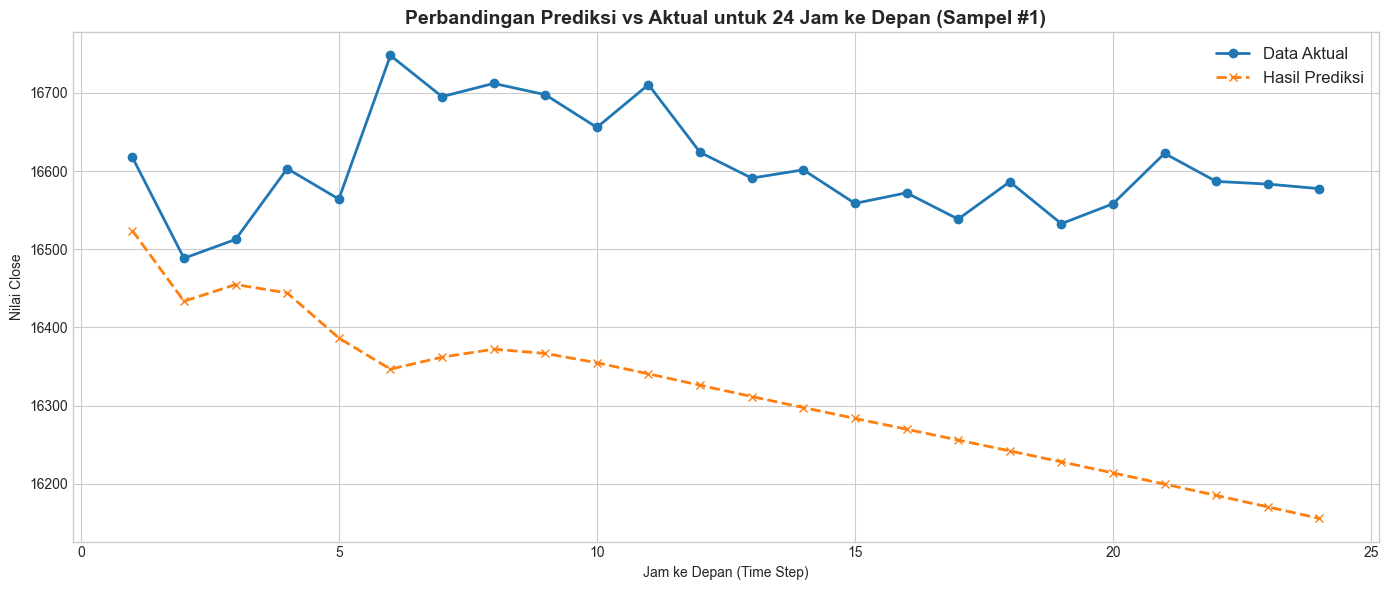

In [26]:
def inverse_transform_target(scaled_arr):
    dummy = np.zeros((len(scaled_arr), len(FEATURES)))
    dummy[:, target_idx] = scaled_arr
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_inv = inverse_transform_target(y_test.reshape(-1)).reshape(y_test.shape)
y_pred_inv = inverse_transform_target(y_pred_scaled.reshape(-1)).reshape(y_pred_scaled.shape)

idx_sample = 0
plt.figure(figsize=(14, 6))
plt.plot(range(1, FORECAST_STEPS + 1), y_test_inv[idx_sample], marker="o", label="Data Aktual", linewidth=2)
plt.plot(range(1, FORECAST_STEPS + 1), y_pred_inv[idx_sample], marker="x", linestyle="--", label="Hasil Prediksi", linewidth=2)
plt.title(f"Perbandingan Prediksi vs Aktual untuk 24 Jam ke Depan (Sampel #{idx_sample+1})", fontweight="bold", fontsize=14)
plt.xlabel("Jam ke Depan (Time Step)")
plt.ylabel("Nilai Close")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
df_pred = pd.DataFrame({
    "Jam ke": range(1, FORECAST_STEPS + 1),
    "Data Aktual": y_test_inv[idx_sample],
    "Hasil Prediksi": y_pred_inv[idx_sample],
})
df_pred["Selisih"] = np.abs(df_pred["Data Aktual"] - df_pred["Hasil Prediksi"])

print("Tabel Perbandingan Data Aktual vs Hasil Prediksi:")
display(df_pred.round(4).style.set_caption(""))

overall_mae = mean_absolute_error(y_test_inv.reshape(-1), y_pred_inv.reshape(-1))
overall_rmse = np.sqrt(mean_squared_error(y_test_inv.reshape(-1), y_pred_inv.reshape(-1)))
print(f"\nMetrik Evaluasi dalam skala asli:")
print(f"MAE: {overall_mae:.2f}")
print(f"RMSE: {overall_rmse:.2f}")

Tabel Perbandingan Data Aktual vs Hasil Prediksi:


,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,16617.470300,16523.771000,93.699200
1,2,16488.409800,16433.424500,54.985400
2,3,16512.510400,16454.782000,57.728400
3,4,16603.109600,16444.023700,159.085900
4,5,16564.070000,16386.370500,177.699500
5,6,16747.830000,16346.561200,401.268800
6,7,16695.179800,16361.854400,333.325500
7,8,16712.069800,16372.055700,340.014200
8,9,16697.689700,16366.643900,331.045800
9,10,16655.799800,16354.702400,301.097400



Metrik Evaluasi dalam skala asli:
MAE: 353.29
RMSE: 507.19


### Inference, Denormalisasi dan Visualisasi Baseline LSTM

In [ ]:
# Inferensi model Baseline LSTM
y_pred_baseline_scaled = model_baseline.predict(X_test)
mae_baseline_scaled = mean_absolute_error(y_test, y_pred_baseline_scaled)
print(f"MAE Scaled Baseline LSTM: {mae_baseline_scaled:.5f}")


247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE Scaled Baseline LSTM: 0.01302


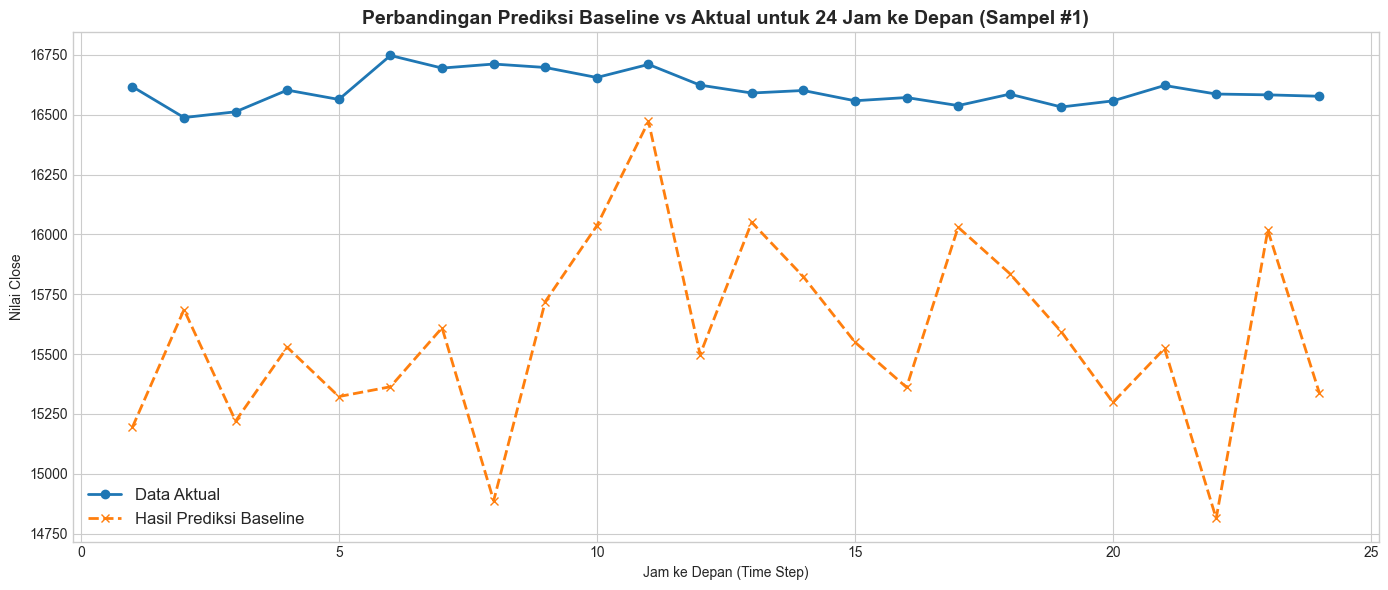

In [29]:
# Denormalisasi dan visualisasi
y_pred_baseline_inv = inverse_transform_target(y_pred_baseline_scaled.reshape(-1)).reshape(y_pred_baseline_scaled.shape)

idx_sample = 0
plt.figure(figsize=(14, 6))
plt.plot(range(1, FORECAST_STEPS + 1), y_test_inv[idx_sample], marker="o", label="Data Aktual", linewidth=2)
plt.plot(range(1, FORECAST_STEPS + 1), y_pred_baseline_inv[idx_sample], marker="x", linestyle="--", label="Hasil Prediksi Baseline", linewidth=2)
plt.title(f"Perbandingan Prediksi Baseline vs Aktual untuk {FORECAST_STEPS} Jam ke Depan (Sampel #{idx_sample+1})", fontweight="bold", fontsize=14)
plt.xlabel("Jam ke Depan (Time Step)")
plt.ylabel("Nilai Close")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
df_pred_baseline = pd.DataFrame({
    "Jam ke": range(1, FORECAST_STEPS + 1),
    "Data Aktual": y_test_inv[idx_sample],
    "Hasil Prediksi": y_pred_baseline_inv[idx_sample],
})
df_pred_baseline["Selisih"] = np.abs(df_pred_baseline["Data Aktual"] - df_pred_baseline["Hasil Prediksi"])

print("Tabel Perbandingan Data Aktual vs Hasil Prediksi Baseline LSTM:")
display(df_pred_baseline.round(4).style.set_caption(""))

overall_mae_baseline = mean_absolute_error(y_test_inv.reshape(-1), y_pred_baseline_inv.reshape(-1))
overall_rmse_baseline = np.sqrt(mean_squared_error(y_test_inv.reshape(-1), y_pred_baseline_inv.reshape(-1)))
print(f"\nMetrik Evaluasi Baseline dalam skala asli:")
print(f"MAE: {overall_mae_baseline:.2f}")
print(f"RMSE: {overall_rmse_baseline:.2f}")


Tabel Perbandingan Data Aktual vs Hasil Prediksi Baseline LSTM:


,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,16617.470300,15194.198300,1423.271900
1,2,16488.409800,15685.424500,802.985300
2,3,16512.510400,15220.100600,1292.409800
3,4,16603.109600,15528.428100,1074.681600
4,5,16564.070000,15322.451100,1241.618900
5,6,16747.830000,15363.364600,1384.465400
6,7,16695.179800,15609.720500,1085.459400
7,8,16712.069800,14887.353500,1824.716300
8,9,16697.689700,15719.291300,978.398400
9,10,16655.799800,16036.352100,619.447700



Metrik Evaluasi Baseline dalam skala asli:
MAE: 852.51
RMSE: 1038.34


### Simpan Model

In [31]:
model_baseline.save("model_baseline_LSTM.keras")
model_seq2seq.save("model_seq2seq_LSTM.keras")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [32]:
!pip freeze > requirements.txt